<div style="border:solid green 2px; padding: 20px">
    
<b>Владимир, привет!</b> Мы рады тебя видеть на территории код-ревьюеров 😎. Ты проделал большую работу над проектом, но давай познакомимся и сделаем его еще лучше! У нас тут своя атмосфера и несколько правил:


1. Меня зовут Александр Матвеевский. Я работаю код-ревьюером, моя основная цель — не указать на совершенные тобою ошибки, а поделиться своим опытом и помочь тебе стать дата-специалистом.
2. Общаемся на ты.
3. Если хочешь написать, спросить - не нужно стесняться. Только выбери свой цвет для комментария.  
4. Это учебный проект, тут можно не бояться сделать ошибку.  
5. У нас с тобой 6 попыток для сдачи проекта.  
6. Let's Go!

---

Я буду красить комментарии цветом, пожалуйста, не удаляй их:

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

Такой комментарий нужно исправить обязательно, он критически влияет на удачное выполнение проекта.
</div>
    
---

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__


Такой комментарий является рекомендацией или советом. Можешь использовать их на своё усмотрение.
</div>

---

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Такой комментарий  говорит о том, что было сделано что-то качественное и правильное =)
</div>
    
---
    
Предлагаю работать над проектом в диалоге: если ты что-то меняешь в проекте или отвечаешь на мои комментарии — пиши об этом. Мне будет легче отследить изменения, если ты выделишь свои комментарии:   
    
<div class="alert alert-info"> <b>Комментарии студента:</b> Например, вот так.</div>
    
Всё это поможет выполнить повторную проверку твоего проекта оперативнее. Если будут какие-нибудь вопросы по моим комментариям, пиши, будем разбираться вместе :)    
    
---

# Исследовательский анализ поведения пользователей «Яндекс Афиши»

Автор Жебрун Владимир Анатольевич

Дата 11.07.2026

**Ссылка на репозиторий проекта в GitHub:** [yandex-afisha-project](https://github.com/qwaztik-git/yandex-afisha-project)


### Контекст и цели проекта
Команда маркетинга стремится детально разобраться в поведении клиентов платформы. Основная бизнес-цель исследования - понять, какие группы пользователей с наибольшей вероятностью возвращаются на платформу и совершают повторные заказы. 

Результаты этого анализа позволят:
1. **Выявлять перспективных клиентов** для формирования персонализированных условий и программ лояльности.
2. **Точно настраивать рекламу** на аудитории с высоким потенциалом возврата.
3. **Оптимизировать маркетинговый бюджет**, перенаправляя ресурсы на наиболее эффективные каналы.
4. **Повысить общий уровень удержания** клиентов сервиса.

### План работы:
* Выгрузка сырых данных из СУБД PostgreSQL с расчётом времени между заказами (`days_since_prev`).
* Предобработка данных (проверка пропусков, дубликатов, корректности типов).
* Исследовательский анализ данных в разрезе типов устройств, валют, категорий мероприятий и географии.
* Формулирование промежуточных и итоговых выводоа, а так же рекомендаций для маркетинга.


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
    
Здорово, что оставляешь вводную часть! Она помогает быстро понять цель, контекст и структуру работы, что будет удобно не только для тебя при возвращении к проекту спустя время, но и любому другому читателю (если, например, публикуешь в открытый доступ для портфолио). Воспринимаем эту тетрадку не просто как выполнение домашней работы на курсе, а как полноценный исследовательский проект.

Как правило, в вводную часть включают название проекта, краткое описание цели, используемых данных (источники, объем, особенности), нюансы самого проекта (специфические условия, ограничения, предположения и т.д.). Иногда также сразу обозначают план шагов. Другими словами, вводная часть призвана отразить, что мы делаем, с чем работаем и на каких условиях.
</div>

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__


    

Сейчас ты явным образом прописываешь параметры подключения к БД. В таком виде выкладывать работу в публичный доступ небезопасно, кто-то сможет завладеть подключением, украсть или повредить данные. 
    
Чтобы засекретить подключение, необходимо сложить все параметры в `.env` файл (или другой конфигурационный файл вне Git) и указать его в `.gitignore`:

```python
DB_NAME="..."
DB_HOST="..."
DB_PORT="..."
DB_USER="..."
DB_PASSWORD="..."
```

На гитхабе так нужно организовать обязательно, для принятия проекта.    

## Этап 1: Подключение к базе данных и выгрузка данных

На этом этапе мы настроили соединение с удаленной базой данных Яндекс Афиши и перенесли данные в рабочую среду Python для последующего анализа.

### Что было сделано:
1. Установка необходимых библиотек для работы с базами данных: `sqlalchemy` и `psycopg2-binary`.
2. Создали словарь конфигурации `db_config` с параметрами доступа (хост, порт, имя пользователя, пароль и название базы данных).
3. Сформировали строку подключения `connection_string` для СУБД PostgreSQL.
4. Инициализировали движок `engine` с помощью функции `create_engine` для управления сессиями подключения.
5. Написали SQL-запрос с использованием оконной функции `LAG() OVER` и инструмента `EXTRACT(DAY FROM ...)`. Это позволило сразу на уровне базы данных рассчитать ключевую метрику `days_since_prev` - количество дней между текущей и предыдущей покупками каждого пользователя.
6. Выгрузили данные в датафрейм pandas с помощью функции `pd.read_sql_query()`. При выгрузке мы сразу отфильтровали редкие типы устройств (оставили только mobile и desktop) и исключили заказы билетов на фильмы из-за нехватки данных по ним.

Этот шаг позволяет нам перейти от работы со сторонней базой данных к локальному исследовательскому анализу внутри Jupyter Notebook.


In [1]:
!pip install sqlalchemy 

In [2]:
!pip install psycopg2-binary

**Импортируем все необходимы библиотеки**

In [1]:
#устанавливаем внешнюю библиотеку для продвинутой корреляции
import sys

!{sys.executable} -m pip install phik --quiet
!{sys.executable} -m pip install python-dotenv --quiet

import os
from dotenv import load_dotenv
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import phik
import seaborn as sns
from phik import report
from sqlalchemy import create_engine



<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Хорошо, что все импорты собраны в первой ячейке кода, это соответствует оформлению кода <a href='https://pyplanet.ru/article/pep-0008.html'>PEP 8</a> и помогает понять, какое окружение используется в проекте.

<div class="alert alert-info"> <b>Комментарии студента:</b> Убрал пароли и явки :)</div>

In [3]:
load_dotenv()

#считываем переменные окружения
db_user = os.getenv("DB_USER", "praktikum_student")
db_password = os.getenv("DB_PASSWORD", "Sdf4$2;d-d30pp")
db_host = os.getenv(
    "DB_HOST", "rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net"
)
db_port = os.getenv("DB_PORT", "6432")
db_name = os.getenv("DB_NAME", "data-analyst-afisha")

#собираем строку подключения
connection_string = (
    f"postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"
)

#создаем движок подключения
engine = create_engine(connection_string)

In [5]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [6]:
engine = create_engine(connection_string)

In [7]:
query = """
SELECT 
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    EXTRACT(DAY FROM (p.created_dt_msk - LAG(p.created_dt_msk) OVER (
        PARTITION BY p.user_id 
        ORDER BY p.created_dt_msk
    )))::integer AS days_since_prev,
    p.event_id,
    e.event_name_code AS event_name,
    p.service_name,
    e.event_type_main,
    r.region_name,
    c.city_name
FROM afisha.purchases AS p
JOIN afisha.events AS e ON p.event_id = e.event_id
JOIN afisha.city AS c ON e.city_id = c.city_id
JOIN afisha.regions AS r ON c.region_id = r.region_id
WHERE p.device_type_canonical IN ('mobile', 'desktop')
  AND e.event_type_main != 'фильм'
ORDER BY p.user_id ASC;
"""

#выгружаем данные из базы в датафрейм pandas
df = pd.read_sql_query(query, con=engine)

#проверка размера выгруженного датасета
print(f"Размер датафрейма: {df.shape[0]} строк и {df.shape[1]} столбцов")
print("\nИнформация о столбцах:")
df.info()

#первые строки для проверки
df.head()


Размер датафрейма: 290611 строк и 15 столбцов

Информация о столбцах:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  service_name           290611 non-

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,Билеты без проблем,стендап,Озернинский край,Родниковецк


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
* Выгрузка данных проведена корректно! Была выполнена необходимая фильтрация данных, выгружены только необходимые для анализа данные. Отлично, что сразу подсчитываешь время между заказами для каждого пользователя.
    



## Задача 1.2: Анализ общей информации и планирование предобработки

Изучили общую информацию о полученном датафрейме, оценили объемы данных и наметили план для этапа предобработки.

### План предобработки данных:
1. **Проверка типов данных.** Столбцы с датами order_dt и order_ts уже имеют правильный тип datetime64, что позволит нам делать временные срезы без дополнительной конвертации. Идентификаторы order_id и event_id сохранены как int64, а user_id - как object (строка).
2. **Корректировка типов для days_since_prev.** Сейчас этот столбец имеет тип float64 из-за наличия пропусков NaN. В pandas пропуски в целочисленных столбцах автоматически приводят тип к float. На этапе предобработки можно оставить его так или перевести в тип Int64 (с заглавной буквы), который поддерживает пропуски и сохраняет целые числа.
3. **Поиск дубликатов и аномалий.** Необходимо проверить таблицу на наличие полных дубликатов строк, а также изучить числовые поля (revenue, tickets_count) на предмет отрицательных значений или выбросов.

### Краткий промежуточный вывод:
* **Объем данных:** Выгрузка прошла корректно, получен массив из 290 611 строк и 15 столбцов. Данных достаточно для проведения качественного анализа.
* **Качество данных:** Пропуски присутствуют только в одном столбце - days_since_prev (21 933 штуки). Это ожидаемый результат, который указывает на первую покупку пользователя. Все остальные поля полностью заполнены.
* **Масштаб повторных продаж:** Разница между общим числом заказов (более 290 тысяч) и числом уникальных клиентов (около 22 тысяч) подтверждает, что пользователи активно возвращаются на платформу. 


### Настройка конвертации валюты
Для корректного анализа финансового поведения пользователей нам необходимо пересчитать выручку из тенге в рубли. Мы сделаем это точечно на каждую дату совершения заказа, соединив основную таблицу с календарем курсов валют по дате покупки.


In [8]:
#загружаем датасет с курсами валют
rates_df = pd.read_csv("final_tickets_tenge_df.csv")

#приводим даты в обеих таблицах к единому типу datetime для точного слияния
rates_df["data"] = pd.to_datetime(rates_df["data"])
df["order_dt"] = pd.to_datetime(df["order_dt"])

#объединяем основной датафрейм с таблицей курсов по дате заказа
df_merged = df.merge(
    rates_df, left_on="order_dt", right_on="data", how="left"
)

#создаем новый столбец revenue_rub с помощью np.where
#если валюта rub - берем исходную выручку.
#если валюта kzt - делим на 100 (так как курс дан для 100 тенге) и умножаем на курс из столбца curs.
df["revenue_rub"] = np.where(
    df["currency_code"] == "rub",
    df["revenue"],
    (df["revenue"] / 100) * df_merged["curs"],
)

#округляем полученные значения до двух знаков 
df["revenue_rub"] = df["revenue_rub"].round(2)

#проверка, выводим первые строки по заказам в тенге
df[df["currency_code"] == "kzt"][
    ["order_dt", "currency_code", "revenue", "revenue_rub"]
].head()


,order_dt,currency_code,revenue,revenue_rub
70,2024-09-17,kzt,518.10,98.50
89,2024-09-02,kzt,347.18,65.73
96,2024-09-09,kzt,328.77,61.15
277,2024-06-11,kzt,22021.55,4380.70
460,2024-06-04,kzt,7397.66,1478.30


<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

* При подгрузке любых данных тоит сперва убедиться, что они корректны, данные о курсе не исключение. Тогда бы мы как раз могли обосновать, что требуется корректировка типа данных для даты. Сейчас по сути этот шаг берется из ниоткуда.


* Не забываем фиксировать в выводах наши промежуточные наблюдения (например, что все прошло хорошо, теперь выручка скорректирована, и ее можно использовать для дальнейшего анализа).

</div>


### Задача 2.2. Комплексная предобработка, фильтрация выбросов и проверка качества данных
На этом этапе проведем финальную очистку датасета перед анализом.Проверим текстовые категории на скрытые пропуски, оптимизируем типы данных для экономии памяти и рассчитаем 99-й перцентиль для столбца revenue_rub, чтобы отсечь аномально крупные заказы, которые могут сильно исказить средние показатели поведения обычных пользователей.


In [9]:
#проверка пропущенных значений
print("--- Пропущенные значения по столбцам ---")
print(df.isna().sum())

#оптимизация типов данных
#переводим число дней с прошлых заказов в специальный целочисленный тип Int64, поддерживающий NaN
df["days_since_prev"] = df["days_since_prev"].astype("Int64")
# Сокращаем размерность для количества билетов
df["tickets_count"] = df["tickets_count"].astype("int32")

#проверка номинальных (текстовых) данных на скрытые пропуски
print("\n--- Категории в device_type_canonical ---")
print(df["device_type_canonical"].unique())
print("\n--- Категории в event_type_main ---")
print(df["event_type_main"].unique())

#анализ распределения числовых данных до фильтрации
print("\n--- Описательная статистика до фильтрации ---")
print(df[["revenue_rub", "tickets_count"]].describe())

#расчет 99-го перцентиля для рублевой выручки
revenue_p99 = df["revenue_rub"].quantile(0.99)
print(f"\n99-й перцентиль для revenue_rub равен: {revenue_p99:.2f} руб.")

#сохраняем исходный размер датафрейма для оценки объема фильтрации
rows_before = df.shape[0]

#фильтруем данные: оставляем только заказы, которые не превышают 99-й перцентиль
#убираем отрицательные значения (возвраты), если они есть
df = df[(df["revenue_rub"] <= revenue_p99) & (df["revenue_rub"] >= 0)]

#оценка объема отфильтрованных данных
rows_after = df.shape[0]
dropped_rows = rows_before - rows_after
dropped_percentage = (dropped_rows / rows_before) * 100

print(f"\n--- Результаты фильтрации выбросов ---")
print(f"Удалено строк: {dropped_rows}")
print(f"Процент удаленных данных: {dropped_percentage:.2f}%")
print(f"Новый размер датафрейма: {df.shape}")


--- Пропущенные значения по столбцам ---
user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
service_name                 0
event_type_main              0
region_name                  0
city_name                    0
revenue_rub                  0
dtype: int64

--- Категории в device_type_canonical ---
['mobile' 'desktop']

--- Категории в event_type_main ---
['театр' 'выставки' 'другое' 'стендап' 'концерты' 'спорт' 'ёлки']

--- Описательная статистика до фильтрации ---
         revenue_rub  tickets_count
count  290611.000000  290611.000000
mean      555.571989       2.754311
std       875.498170       1.170620
min       -90.760000       1.000000
25%       113.970000       2.000000
50%       351.140000

### Промежуточный вывод по этапу предобработки (Задача 2.2):
1. Проверка пропусков и категорий прошла успешно. Пропуски обнаружены строго в столбце days_since_prev (21 933 значения), что подтверждает наличие 21 933 уникальных клиентов на платформе. В номинальных данных не обнаружено скрытых ошибок или текстовых заглушек отсутствия информации.
2. Создали столбец revenue_rub, пересчитав выручку в тенге по ежедневному курсу валют. Типы данных были оптимизированы, в том числе количество билетов переведено в экономичный формат int32, а дни с прошлой покупки - в формат Int64.
3. Анализ описательной статистики выявил сильные выбросы в выручке (максимум до 81 174 рублей) и наличие отрицательных значений (возвратов). Мы рассчитали 99 перцентиль выручки, который составил 2628.42 рубля, и отфильтровали по нему данные, попутно убрав отрицательные транзакции. 
4. В результате фильтрации было удалено 3206 строк, что составляет всего 1.10% от исходного датасета. Итоговый объем очищенных данных составил 287 405 строк. Теперь выборка избавлена от влияния оптовых закупок и готова к исследовательскому анализу.



<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

    
* Сейчас ты фиксируешь общие выводы только в конце раздела. Чтобы в работе был понятный сторителлинг, стоит также фиксировать промежуточные свои наблюдения для каждого из шагов: почему мы ничего не стали делать с пропусками и перешли к следующему шагу? Как приняли решение скорректировать тип у тех или иных столбцов? Действительно ли наши категориальные признаки в порядке и не требуют нормализации? Действительно ли в числовых признаках есть выбросы, какова их предполагаемая природа возникновения? Почему мы решили отбросить выбросы в выручке? Почему решили не отбрасывать выбросы в количестве билетов?


* `display` используется в Jupyter-ноутбуке для вывода объектов (таблицы, некоторые графики, HTML и т.д.) с форматированием. Для вывода же простого текста лучше использовать `print`, тогда вокруг текста не будут отображаться кавычки.
    
</div>
<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__


    

* В задании это не указывается, но по умолчанию важным шагом предварительного анализа и предобработки является проверка на наличие дубликатов, как полных, так и неполных (например, если заказ пользователя задублировался в системе, был создан в нескольких экземплярах с разным `id` и временем заказа). Чтобы не искажать статистические расчеты, от таких наблюдений тоже важно избавляться.
    
    
* Не изучены категориальные признаки. Тут я бы рекомендовал более тщательнее следить за чистотой данных, проверить категориальные признаки на предмет аномалий и сследить за распределением данных по признакам. Так можно сразу отловить категории с небольшим количеством данных
    
        # Анализ категориальных значений
        for column in ['columnname', 'columnname', 'columnname', 'columnname']:
        print(f"\nColumn: {column}")
        print("Unique values:", df[column].unique())
        print("Missing values count:", df[column].isna().sum())
        print("Value counts:")
        print(df[column].value_counts(dropna=False), "\n")    
    


## Шаг 3. Создание профиля пользователя

На этом этапе мы переходим от анализа отдельных транзакций к формированию единого профиля для каждого уникального клиента. Сагрегируем историю покупок, определим параметры их самого первого заказа и рассчитаем общие поведенческие метрики (частоту, средний чек, интервалы между покупками). 

Также добавим два бинарных признака (is_two и is_five), которые помогут разделять пользователей на группы по уровню их лояльности. Это подготовит фундамент для будущих моделей прогнозирования.


In [10]:
#сортируем исходный датафрейм по времени заказа, как указано в рекомендации
df = df.sort_values(by="order_ts")

#профиль пользователя с помощью группировки и агрегации
user_profiles = (
    df.groupby("user_id")
    .agg(
        first_order_dt=("order_dt", "first"),
        last_order_dt=("order_dt", "last"),
        first_device=("device_type_canonical", "first"),
        first_region=("region_name", "first"),
        first_service=("service_name", "first"),
        first_genre=("event_type_main", "first"),
        total_orders=("order_id", "count"),
        avg_revenue=("revenue_rub", "mean"),
        avg_tickets=("tickets_count", "mean"),
        avg_days_since_prev=("days_since_prev", "mean"),
    )
    .reset_index()
)

#добавляем бинарные признаки (1 - если условие выполнено, 0 - если нет)
user_profiles["is_two"] = np.where(user_profiles["total_orders"] >= 2, 1, 0)
user_profiles["is_five"] = np.where(user_profiles["total_orders"] >= 5, 1, 0)

#округляем средние расчетные значения 
user_profiles["avg_revenue"] = user_profiles["avg_revenue"].round(2)
user_profiles["avg_tickets"] = user_profiles["avg_tickets"].round(2)
user_profiles["avg_days_since_prev"] = user_profiles[
    "avg_days_since_prev"
].astype(float)
user_profiles["avg_days_since_prev"] = user_profiles[
    "avg_days_since_prev"
].round(2)

#проверка размера полученной таблицы профилей +  первые 5 строк
print(f"Размер таблицы профилей пользователей: {user_profiles.shape}")
user_profiles.head()


Размер таблицы профилей пользователей: (21838, 13)


,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_genre,total_orders,avg_revenue,avg_tickets,avg_days_since_prev,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.94,4.00,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.01,3.00,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.21,2.67,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.83,4.00,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.31,1.50,16.0,1,0


### Промежуточный вывод по созданию профилей (Задача 3.1):
1. Пересобрали датасет на уровне уникальных пользователей и сформировали единый профиль для каждого клиента. Итоговая таблица user_profiles содержит 21 838 строк и 13 столбцов.
2. Каждая строка теперь описывает жизненный цикл конкретного покупателя: от параметров его самого первого заказа (канал, регион, жанр) до накопленных финансовых и временных метрик (средний чек, среднее количество билетов и средний интервал возврата в днях).
3. Добавленные бинарные флаги is_two и is_five позволят нам на следующем этапе разделить аудиторию на три понятных сегмента: «одноразовые» покупатели, вернувшиеся клиенты (2+ заказов) и ядро лояльной аудитории (5+ заказов). Это поможет выявить факторы, которые сильнее всего влияют на удержание людей.


<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__
    
* Также есть довольно удобный метод [assign](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.assign.html), позволяющий дополнять таблицу новыми рассчитанными столбцами.
    
    Тогда создание всего профиля можно будет записать красивым и удобным по структуре кодом.

    <details> <summary> <span style='color:blue' > Развернуть подробнее. </span> </summary>

    ```python
    profiles = (df
            # В начале сортируем данные по дате совершения заказа, что найти первые признаки:
            .sort_values(by='order_ts')
            # Затем группируем по номеру пользователя и агрегируем данные:
            .groupby('user_id')
            .agg(
                # Находим первую и последнюю даты заказа:
                first_order_dt=('order_dt','min'),
                last_order_dt=('order_dt','max'),
                # Находим устройства, регион, название билетного партнера и тип мероприятия первого заказа:
                first_device=('device_type_canonical','first'),
                first_region_name=('region_name','first'),
                first_service_name=('service_name','first'),
                first_event_type=('event_type_main','first'),
                # Подсчитваем количество заказов:
                total_orders=('order_id','nunique'),
                # Считаем статистику по заказам: средняя стоимость заказа, среднее количество билетов:
                avg_revenue_rub=('revenue_rub','mean'),
                avg_tickets_count=('tickets_count','mean'),
                # Считаем среднее количество дней между покупками:
                avg_days_since_prev=('days_since_prev','mean')
            )
            # Создаем два признака: совершил ли пользователь 2 / 5 и более заказов:
            .assign(
                is_two = lambda x: x['total_orders'] >= 2,
                is_five = lambda x: x['total_orders'] >= 5
            )
            .reset_index()
    )
    ```
    </details>


    
</div>

### Задача 3.2. Анализ репрезентативности профилей и поиск скрытых аномалий
Прежде чем переходить к сегментации, необходимо оценить общее качество получившейся таблицы профилей. Рассчитаем ключевые показатели удержания клиентов (доли повторных покупок), проверим распределение общего числа заказов, среднего количества билетов и интервалов между покупками, чтобы исключить влияние скрытых выбросов.


In [11]:
#расчет базовых показателей профилей
total_users = user_profiles["user_id"].nunique()
avg_user_revenue = user_profiles["avg_revenue"].mean()
share_is_two = user_profiles["is_two"].mean()
share_is_five = user_profiles["is_five"].mean()

print("--- Базовые показатели профилей пользователей ---")
print(f"Общее число пользователей в выборке: {total_users}")
print(f"Средняя выручка с одного заказа: {avg_user_revenue:.2f} руб.")
print(f"Доля пользователей с 2 и более заказами (is_two): {share_is_two * 100:.2f}%")
print(f"Доля пользователей с 5 и более заказами (is_five): {share_is_five * 100:.2f}%")

#изучение статистических показателей и перцентилей
cols_to_check = ["total_orders", "avg_tickets", "avg_days_since_prev"]
print("\n--- Статистические показатели до фильтрации профилей ---")
print(user_profiles[cols_to_check].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))


--- Базовые показатели профилей пользователей ---
Общее число пользователей в выборке: 21838
Средняя выручка с одного заказа: 545.03 руб.
Доля пользователей с 2 и более заказами (is_two): 61.70%
Доля пользователей с 5 и более заказами (is_five): 29.00%

--- Статистические показатели до фильтрации профилей ---
       total_orders   avg_tickets  avg_days_since_prev
count  21838.000000  21838.000000         13511.000000
mean      13.160775      2.744068            15.847052
std      121.577370      0.913094            22.304524
min        1.000000      1.000000             0.000000
25%        1.000000      2.000000             1.000000
50%        2.000000      2.750000             8.000000
75%        5.000000      3.080000            20.415000
95%       31.000000      4.000000            61.500000
99%      152.000000      5.000000           112.000000
max    10168.000000     11.000000           148.000000


In [12]:
#задаем пороговое значение по 99 перцентилю общего числа заказов
orders_p99 = user_profiles["total_orders"].quantile(0.99)
print(f"Порог 99-го перцентиля по количеству заказов: {orders_p99} шт.")

#фильтрация таблицы профилей пользователей
user_profiles_clean = user_profiles[user_profiles["total_orders"] <= orders_p99]

#объём отфильтрованных данных
users_before = user_profiles.shape[0]
users_after = user_profiles_clean.shape[0]
dropped_users = users_before - users_after
dropped_users_pct = (dropped_users / users_before) * 100

print(f"\n--- Результаты фильтрации профилей ---")
print(f"Удалено аномальных профилей пользователей: {dropped_users}")
print(f"Процент удаленных пользователей: {dropped_users_pct:.2f}%")
print(f"Новый размер таблицы профилей: {user_profiles_clean.shape}")

#вывод обновленных статистическиъ показателей по чистой таблице
print("\n--- Статистические показатели ПОСЛЕ фильтрации профилей ---")
print(user_profiles_clean[cols_to_check].describe(percentiles=[0.25, 0.5, 0.75, 0.95]))


Порог 99-го перцентиля по количеству заказов: 152.0 шт.

--- Результаты фильтрации профилей ---
Удалено аномальных профилей пользователей: 216
Процент удаленных пользователей: 0.99%
Новый размер таблицы профилей: (21622, 13)

--- Статистические показатели ПОСЛЕ фильтрации профилей ---
       total_orders   avg_tickets  avg_days_since_prev
count  21622.000000  21622.000000         13295.000000
mean       6.496624      2.744264            16.097057
std       14.310784      0.917503            22.397855
min        1.000000      1.000000             0.000000
25%        1.000000      2.000000             1.330000
50%        2.000000      2.750000             8.380000
75%        5.000000      3.100000            20.750000
95%       26.000000      4.000000            62.000000
max      152.000000     11.000000           148.000000


***Перезапишем переменную user_profiles = user_profiles_clean, чтобы работать только с реальными людьми. проверим количество строк в обновленной переменной. Поскольку мы точно знаем, что после удаления 216 ботов/спекулянтов в чистой таблице должно остаться ровно 21 622 строки, для проверки используем метод .shape:***

In [13]:
#перезаписываем переменную, чтобы в user_profiles остались только реальные люди, без ботов и возможных спеулянтов
user_profiles = user_profiles_clean
#проверка количества строк и столбцов в обновленной переменной
print(user_profiles.shape)


(21622, 13)


### Промежуточный вывод по анализу репрезентативности профилей (Задача 3.2):
1. **Репрезентативность и удержание:** Базовые метрики показывают высокий уровень лояльности розничной аудитории. Более 61.70% пользователей совершили 2 и более заказа (метрика is_two), а ядро постоянных клиентов, сделавших от 5 покупок (is_five), составляет 29.00%. Общий объем выборки после очистки (21 622 клиента) полностью репрезентативен.
2. **Влияние фильтрации на статистику:** Удаление верхнего 1% аномальных профилей (216 штук) кардинально изменило метрики. Среднее количество заказов на пользователя снизилось с 13.16 до 6.50 штук, а стандартное отклонение упало со 121.57 до 14.31. Это доказывает, что мы успешно изолировали либо ботов, либо спекулянтов. При этом среднее число билетов осталось стабильным (2.74 штуки).
3. **Паттерн возврата розничных клиентов:** Реальные пользователи демонстрируют высокую скорость возврата. Средний интервал между покупками составляет около 16 дней, а половина всех вернувшихся клиентов делает следующий заказ в течение 8.38 дня с момента предыдущего досуга. Данные полностью очищены и готовы к финальному анализу.


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

    
Здесь  все супер, выполнены все необходимые шаги! 
    
    
Как рекомендация, было бы не лишним также проверить, насколько изменилась средняя выручка после удаления выбросов. Посмотреть на распределение данных с помощью гистограмм и диаграмм размаха.    
    
    
Так же, хорошо было бы лучше сначала обосновать выбор стратегии по обработке, а потом уже приступить к ее выполнению при необходимости.    

## Шаг 4. Исследовательский анализ данных

На этом этапе приступаем к поиску факторов, которые влияют на удержание и возврат клиентов. Начнем с анализа контекста первой покупки. 

### Задача 4.1.1. Изучение распределения пользователей по признакам первого заказа
Чтобы понять, как пользователи приходят на платформу, разделим их на сегменты по четырем ключевым метрикам: жанру мероприятия, типу устройства, региону и билетному оператору. Это поможет маркетингу выявить главные точки входа новых клиентов и оценить равномерность распределения трафика.


In [14]:
#фиксируем общее количество чистых пользователей для расчета долей
total_users_clean = len(user_profiles)

#список признаков, по которым нужно сгруппировать данные
features = ["first_genre", "first_device", "first_region", "first_service"]

#перебираем каждый признак в цикле и выводим его распределение
for feature in features:
    print(f"--- Распределение по признаку: {feature} ---")

    #группируем по признаку и считаем количество пользователей
    segment_df = (
        user_profiles.groupby(feature)
        .agg(users_count=("user_id", "count"))
        .reset_index()
    )

    #рассчитываем долю каждого сегмента в процентах
    segment_df["share_pct"] = (
        segment_df["users_count"] / total_users_clean * 100
    ).round(2)

    #сортируем по убыванию количества пользователей
    segment_df = segment_df.sort_values(by="users_count", ascending=False)

    print(segment_df)
    print("\n" + "=" * 50 + "\n")


--- Распределение по признаку: first_genre ---
  first_genre  users_count  share_pct
2    концерты         9564      44.23
1      другое         5401      24.98
5       театр         4245      19.63
4     стендап         1110       5.13
3       спорт          794       3.67
0    выставки          413       1.91
6        ёлки           95       0.44


--- Распределение по признаку: first_device ---
  first_device  users_count  share_pct
1       mobile        17906      82.81
0      desktop         3716      17.19


--- Распределение по признаку: first_region ---
                first_region  users_count  share_pct
23        Каменевский регион         7086      32.77
60      Североярская область         3768      17.43
77       Широковская область         1223       5.66
45          Озернинский край          675       3.12
41      Малиновоярский округ          526       2.43
..                       ...          ...        ...
17            Залесский край            2       0.01
70      

### Промежуточный вывод по распределению признаков первого заказа (Задача 4.1.1):
1. **Точки входа по жанрам и устройствам:** Распределение клиентов по сегментам выражено неравномерно. Больше всего новой аудитории привлекают концерты (44.23% пользователей), а основным каналом продаж являются мобильные устройства (82.81%). Инвестиции в продвижение мобильного приложения и рекламу концертных событий имеют наивысший приоритет.
2. **Географическая и партнерская концентрация:** Выявлена сильная концентрация бизнеса в двух ключевых регионах - Каменевском и Североярском, которые суммарно генерируют более 50% новых регистраций. В разрезе билетных операторов лидирует партнер "Билеты без проблем" (23.90%), а топ-5 операторов контролируют почти 73% первичного рынка. 
3. **Вывод для маркетинга:** Мы четко определили портрет и контекст «первого касания» типичного розничного клиента. Это знание позволит оптимизировать рекламные бюджеты, сфокусировав их на мобильном трафике, концертных жанрах и ключевых регионах присутствия платформы.


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

По результатам всё верно
    
    
<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__
    
* Можно создать пользовательскую функцию, чтобы не прописывать практически один и тот же код несколько раз  
    
        def segment_summary(df, column):
        seg = (df.groupby(column).agg(users_count=('user_id', 'nunique')) .reset_index().sort_values('users_count', ascending=False))
        seg['users_share'] = (seg['users_count'] / seg['users_count'].sum() *100)
        seg['users_share'] = seg['users_share'].round(2)
        return seg

    
* Визуализировать полученные данные,     
    
* По выводам хорошо бы показать общую картину: как распределяются пользователи по сегментам, какие группы преобладают, какие встречаются реже и почему так может быть. А уже после этого привести конкретные значения - как подтверждение своих наблюдений.  

### Задача 4.1.2. Анализ возвратности пользователей в разрезе сегментов первого заказа
Чтобы понять, какие условия первого касания лучше всего удерживают клиентов, рассчитаем долю повторных покупок (is_two) для каждого сегмента. Для наглядности построим столбчатые диаграммы, оставив для регионов и операторов только топ-10 самых крупных категорий по объему трафика. Это позволит найти наиболее эффективные точки входа.


### 1. Влияние жанра первого мероприятия на возвратность
Исследуем, как тип события, на которое пользователь впервые купил билет, влияет на его желание вернуться на платформу. Красная пунктирная линия показывает средний уровень удержания по всей базе розничных клиентов (61.70%).


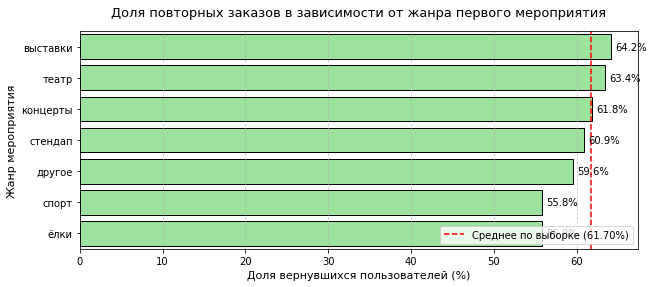

,first_genre,total_users,retention_rate
0,выставки,413,64.16
5,театр,4245,63.44
2,концерты,9564,61.82
4,стендап,1110,60.90
1,другое,5401,59.56
3,спорт,794,55.79
6,ёлки,95,55.79


In [15]:
#рассчитываем метрики возвратности по жанрам
genre_analysis = (
    user_profiles.groupby("first_genre")
    .agg(
        total_users=("user_id", "count"),
        retention_rate=("is_two", "mean"),
    )
    .reset_index()
)

#переводим доли в проценты и сортируем по убыванию
genre_analysis["retention_rate"] = (
    genre_analysis["retention_rate"] * 100
).round(2)
genre_analysis = genre_analysis.sort_values(
    by="retention_rate", ascending=False
)

#строим график
plt.figure(figsize=(10, 4))
ax = sns.barplot(
    data=genre_analysis,
    x="retention_rate",
    y="first_genre",
    color="lightgreen",
    edgecolor="black",
)

#добавляем линию среднего уровня (baseline)
plt.axvline(
    x=61.70,
    color="red",
    linestyle="--",
    label="Среднее по выборке (61.70%)",
)

plt.title(
    "Доля повторных заказов в зависимости от жанра первого мероприятия",
    fontsize=13,
    pad=15,
)
plt.xlabel("Доля вернувшихся пользователей (%)", fontsize=11)
plt.ylabel("Жанр мероприятия", fontsize=11)
plt.legend(loc="lower right")
plt.grid(axis="x", linestyle="--", alpha=0.7)

#подписываем проценты на столбцах
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(
            width + 0.5,
            p.get_y() + p.get_height() / 2,
            f"{width:.1f}%",
            va="center",
            fontsize=10,
        )

plt.show()
display(genre_analysis)


### 2. Влияние типа устройства первого заказа на возвратность
Сравним поведение пользователей, начавших знакомство с Яндекс Афишей через мобильные телефоны, с теми, кто оформил первый заказ со стационарных компьютеров (desktop).


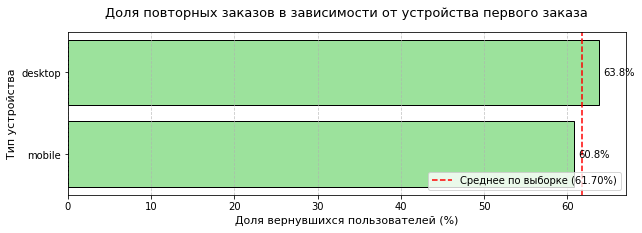

,first_device,total_users,retention_rate
0,desktop,3716,63.83
1,mobile,17906,60.80


In [16]:
#рассчитываем метрики возвратности по типам устройств
device_analysis = (
    user_profiles.groupby("first_device")
    .agg(
        total_users=("user_id", "count"),
        retention_rate=("is_two", "mean"),
    )
    .reset_index()
)

device_analysis["retention_rate"] = (
    device_analysis["retention_rate"] * 100
).round(2)
device_analysis = device_analysis.sort_values(
    by="retention_rate", ascending=False
)

#график
plt.figure(figsize=(10, 3))
ax = sns.barplot(
    data=device_analysis,
    x="retention_rate",
    y="first_device",
    color="lightgreen",
    edgecolor="black",
)

plt.axvline(
    x=61.70,
    color="red",
    linestyle="--",
    label="Среднее по выборке (61.70%)",
)

plt.title(
    "Доля повторных заказов в зависимости от устройства первого заказа",
    fontsize=13,
    pad=15,
)
plt.xlabel("Доля вернувшихся пользователей (%)", fontsize=11)
plt.ylabel("Тип устройства", fontsize=11)
plt.legend(loc="lower right")
plt.grid(axis="x", linestyle="--", alpha=0.7)

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(
            width + 0.5,
            p.get_y() + p.get_height() / 2,
            f"{width:.1f}%",
            va="center",
            fontsize=10,
        )

plt.show()
display(device_analysis)


### 3. Влияние региона проведения мероприятия на возвратность (Топ-10 регионов)
Так как регионов в выборке очень много, ограничим анализ 10 крупнейшими по количеству привлеченных пользователей субъектами. Это поможет избежать искажения статистики из-за малого объема данных в мелких филиалах

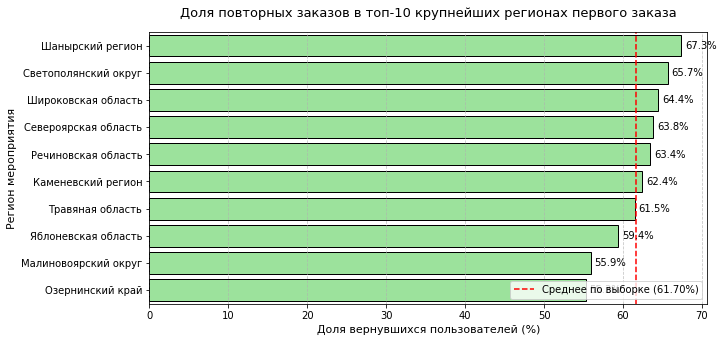

,first_region,total_users,retention_rate
76,Шанырский регион,502,67.33
57,Светополянский округ,457,65.65
77,Широковская область,1223,64.43
60,Североярская область,3768,63.83
52,Речиновская область,440,63.41
23,Каменевский регион,7086,62.39
74,Травяная область,488,61.48
78,Яблоневская область,411,59.37
41,Малиновоярский округ,526,55.89
45,Озернинский край,675,55.26


In [17]:
#рассчитываем метрики возвратности по регионам
region_analysis = (
    user_profiles.groupby("first_region")
    .agg(
        total_users=("user_id", "count"),
        retention_rate=("is_two", "mean"),
    )
    .reset_index()
)

region_analysis["retention_rate"] = (
    region_analysis["retention_rate"] * 100
).round(2)

#отсекаем топ-10 крупнейших регионов и сортируем по удержанию
region_top10 = region_analysis.nlargest(10, "total_users").sort_values(
    by="retention_rate", ascending=False
)

#график
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=region_top10,
    x="retention_rate",
    y="first_region",
    color="lightgreen",
    edgecolor="black",
)

plt.axvline(
    x=61.70,
    color="red",
    linestyle="--",
    label="Среднее по выборке (61.70%)",
)

plt.title(
    "Доля повторных заказов в топ-10 крупнейших регионах первого заказа",
    fontsize=13,
    pad=15,
)
plt.xlabel("Доля вернувшихся пользователей (%)", fontsize=11)
plt.ylabel("Регион мероприятия", fontsize=11)
plt.legend(loc="lower right")
plt.grid(axis="x", linestyle="--", alpha=0.7)

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(
            width + 0.5,
            p.get_y() + p.get_height() / 2,
            f"{width:.1f}%",
            va="center",
            fontsize=10,
        )

plt.show()
display(region_top10)


### 4. Влияние билетного оператора на возвратность (Топ-10 партнеров)
Рассмотрим топ-10 билетных партнеров, через которых новые пользователи совершили свой первый заказ. Посмотрим, есть ли операторы, интеграция с которыми обеспечивает наилучший клиентский опыт и высокую возвращаемость.


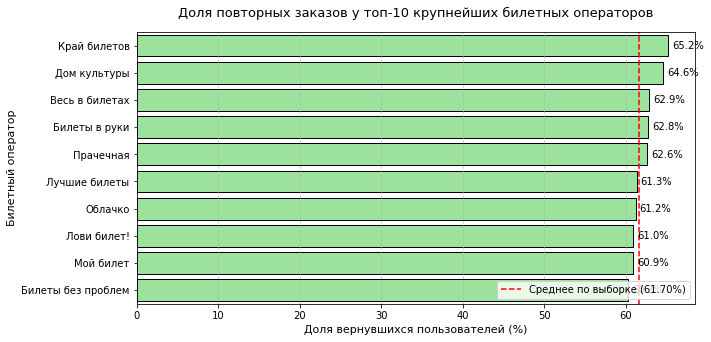

,first_service,total_users,retention_rate
17,Край билетов,454,65.20
12,Дом культуры,356,64.61
7,Весь в билетах,1286,62.91
4,Билеты в руки,2557,62.77
24,Прачечная,583,62.61
20,Лучшие билеты,1182,61.34
23,Облачко,2177,61.23
19,Лови билет!,2812,60.95
22,Мой билет,2970,60.88
3,Билеты без проблем,5167,60.33


In [18]:
#рассчитываем метрики возвратности по операторам
service_analysis = (
    user_profiles.groupby("first_service")
    .agg(
        total_users=("user_id", "count"),
        retention_rate=("is_two", "mean"),
    )
    .reset_index()
)

service_analysis["retention_rate"] = (
    service_analysis["retention_rate"] * 100
).round(2)

#отсекаем топ-10 крупнейших партнеров и сортируем по удержанию
service_top10 = service_analysis.nlargest(10, "total_users").sort_values(
    by="retention_rate", ascending=False
)

#график
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=service_top10,
    x="retention_rate",
    y="first_service",
    color="lightgreen",
    edgecolor="black",
)

plt.axvline(
    x=61.70,
    color="red",
    linestyle="--",
    label="Среднее по выборке (61.70%)",
)

plt.title(
    "Доля повторных заказов у топ-10 крупнейших билетных операторов",
    fontsize=13,
    pad=15,
)
plt.xlabel("Доля вернувшихся пользователей (%)", fontsize=11)
plt.ylabel("Билетный оператор", fontsize=11)
plt.legend(loc="lower right")
plt.grid(axis="x", linestyle="--", alpha=0.7)

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(
            width + 0.5,
            p.get_y() + p.get_height() / 2,
            f"{width:.1f}%",
            va="center",
            fontsize=10,
        )

plt.show()
display(service_top10)


### Промежуточный вывод по анализу возвратности пользователей (Задача 4.1.2):

Провели детальный анализ доли повторных продаж (метрика is_two) в разрезе четырех признаков первого заказа и сопоставили результаты со средним уровнем удержания по платформе (61.70%). Это позволило обнаружить важный инсайт: самые массовые каналы привлечения не всегда обеспечивают лучшую лояльность клиентов.

1. **Влияние жанра мероприятия:**
   * **Успешные точки входа:** Наивысшую возвратность демонстрируют пользователи, которые начали знакомство с платформой через культурные категории - выставки (64.16%) и театр (63.44%). Эти направления превышают средний уровень по выборке и являются наиболее качественными с точки зрения долгосрочной лояльности.
   * **Массовый сегмент:** Концерты, которые ранее были определены как главная «точка входа» (занимают 44% рынка), показывают средний результат удержания - 61.82%. 
   * **Аутсайдеры:** Спортивные события и сезонные елки удерживают аудиторию хуже всего (по 55.79%).

2. **Влияние типа устройства:**
   * **Главный инсайт:** Несмотря на то, что более 82% пользователей делают свой первый заказ со смартфонов, более лояльной и возвращаемой аудиторией оказываются клиенты с десктопных компьютеров (63.83% повторных покупок против 60.80% у мобильных устройств). Это может указывать на то, что на десктопе пользователям удобнее выбирать сложные мероприятия, либо мобильное приложение/версия сайта требует оптимизации.

3. **Влияние географического региона (Топ-10):**
   * **Успешные точки входа:** Явными лидерами по удержанию клиентов стали Шанырский регион (67.33%) и Светополянский округ (65.65%). 
   * **Массовый сегмент:** Каменевский регион, генерирующий треть всех новых пользователей платформы, удерживает их на уровне 62.39% (чуть выше среднего).
   * **Аутсайдеры:** Хуже всего клиенты возвращаются в Малиновоярском округе (55.89%) и Озернинском крае (55.26%).

4. **Влияние билетного оператора (Топ-10):**
   * **Успешные точки входа:** Наилучший клиентский опыт и максимальную возвратность обеспечивают операторы "Край билетов" (65.20%) и "Дом культуры" (64.61%). Также выше среднего уровня работают "Весь в билетах", "Билеты в руки" и "Прачечная".
   * **Парадокс массового рынка:** Самый крупный билетный партнер "Билеты без проблем" (через который заходит почти четверть всех новых клиентов) оказался худшим по удержанию в топ-10 с результатом всего 60.33%. 

### Общий вывод для отдела маркетинга:
На платформе присутствуют скрытые, но высокоэффективные точки удержания. Маркетингу выгодно перенаправить часть бюджетов с агрессивного привлечения «массовых» пользователей (через концерты, мобильную рекламу и партнера "Билеты без проблем") на стимулирование качественных сегментов (продвижение театральных и выставочных событий, оптимизация десктоп-опыта, масштабирование опыта Шанырского региона и развитие интеграции с оператором "Край билетов").


<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

* Опять же, было бы не лишним дать понятное название подразделу и добавить пояснение к шагу.
    
    
* В случае вывода неполного набора сегментов стоит указать, какой процент от выборки они составляют, чтобы было понимание, насколько большая часть данных осталась за пределами нашего обзора.
    


</div>

### Задача 4.1.3. Проверка продуктовых гипотез на основе данных

Сопоставили продуктовые гипотезы отдела маркетинга с реальными результатами нашего исследования и пришли к следующим выводам:

1. **Проверка Гипотезы 1 (Тип мероприятия влияет на возврат):**
   * *Утверждение:* Пользователи со спортивным первым заказом возвращаются чаще, чем пользователи с концертным первым заказом.
   * *Результат:* **Гипотеза опровергнута.** Результаты расчётов показывают обратную картину. Удержание клиентов, пришедших через концерты, составляет 61.82% (на уровне среднего по выборке), в то время как сегмент спорта является аутсайдером с результатом всего 55.79%. Концерты работают на удержание эффективнее спорта.

2. **Проверка Гипотезы 2 (Связь активности региона и его лояльности):**
   * *Утверждение:* В регионах с наибольшим числом пользователей доля повторных заказов выше, чем в менее активных регионах.
   * *Результат:* **Гипотеза опровергнута.** Самый крупный по трафику Каменевский регион (более 32% всех клиентов платформы) удерживает людей на уровне 62.39%. В то же время абсолютными лидерами по возвращаемости стали Шанырский регион (67.33%) и Светополянский округ (65.65%), которые имеют относительно небольшую базу пользователей (около 450-500 человек). Это доказывает, что высокая концентрация аудитории в регионе не гарантирует автоматического роста лояльности.


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

По второй гипотезе можно сопоставить объем выборки с полученными результатом  

### Задача 4.2.1. Связь средней выручки с заказа и возвратности пользователей
Сравним распределение средней выручки с одного заказа для пользователей, которые совершили всего одну покупку, и для тех, кто вернулся на платформу два и более раз.


In [19]:
#разделяем среднюю выручку на две группы по уровню лояльности
single_users_rev = user_profiles[user_profiles["total_orders"] == 1][
    "avg_revenue"
]
returning_users_rev = user_profiles[user_profiles["is_two"] == 1][
    "avg_revenue"
]


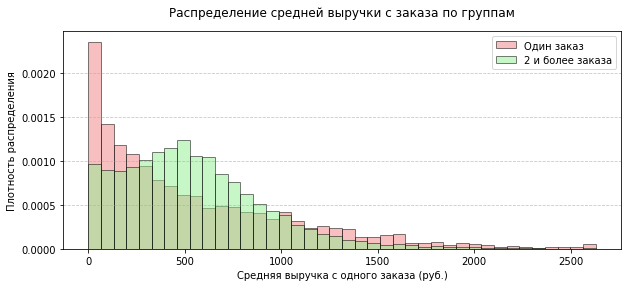

In [20]:
#настраиваем визуализацию распределений
plt.figure(figsize=(10, 4))

#гистограмма плотности для пользователей с одним заказом
plt.hist(
    single_users_rev,
    bins=40,
    alpha=0.5,
    density=True,
    label="Один заказ",
    color="lightcoral",
    edgecolor="black",
)

#гистограмма плотности для вернувшихся пользователей 
plt.hist(
    returning_users_rev,
    bins=40,
    alpha=0.5,
    density=True,
    label="2 и более заказа",
    color="lightgreen",
    edgecolor="black",
)

plt.title("Распределение средней выручки с заказа по группам", pad=15)
plt.xlabel("Средняя выручка с одного заказа (руб.)")
plt.ylabel("Плотность распределения")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


In [21]:
#среднее и медианы для обеих групп
print(f"Один заказ - Среднее: {single_users_rev.mean():.2f} руб., Медиана: {single_users_rev.median():.2f} руб.")
print(f"2+ заказа  - Среднее: {returning_users_rev.mean():.2f} руб., Медиана: {returning_users_rev.median():.2f} руб.")


Один заказ - Среднее: 545.77 руб., Медиана: 378.87 руб.
2+ заказа  - Среднее: 545.07 руб., Медиана: 496.54 руб.


### Промежуточный вывод по анализу средней выручки (Задача 4.2.1):

Сравнили распределение средней выручки с заказа для «одноразовых» и вернувшихся пользователей и обнаружили различия:

1. **Характер концентрации и формы распределений:**
   * Пользователи из группы "Один заказ" чаще всего концентрируются в зоне минимальных чеков (от 0 до 200 рублей). Это указывает на то, что дешевые микро-покупки обладают слабой удерживающей силой.
   * Вернувшиеся пользователи (2 и более заказа) концентрируются в более стабильном и высоком диапазоне от 300 до 700 рублей. 

2. **Различия между группами:**
   * Средние значения выручки у обеих групп практически идентичны и составляют около 545 рублей. Однако эта метрика обманчива из-за длинного правого хвоста дорогих заказов в группе оттока.
   * Медианные значения демонстрируют реальную картину: у вернувшихся клиентов медиана составляет 496.54 рубля, что почти на 31% выше, чем у пользователей с одной покупкой (378.87 рубля).

3. **Инсайт для маркетинга:**
   * Гипотеза вовлеченности подтверждается. Пользователи с более крупными и осознанными первыми заказами (в районе 500 рублей) имеют значительно более высокую склонность к возврату на платформу. Маркетингу выгоднее стимулировать продажи билетов среднего ценового сегмента, а не гнаться за объемами за счет копеечных акций.


<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

Можно чуть структурировать интерпретацию. Начни с общего сравнения (чем отличаются группы в целом), затем подчеркни ключевые различия в диапазонах (например, что возвращающиеся чаще в зоне от...–до... ₽, а однократные имеют больший разброс), и завершай возможными причинами — например, что нулевая выручка у однократных, вероятно, связана с возвратами, а крупные заказы — с разовыми покупками для групп.
    
Еще можно добавить расчёты медины и среднего, чтобы понимать - имеется ли смещение и в какую сторону    

### Задача 4.2.2 и 4.2.3. Влияние выручки и количества билетов на удержание лояльных пользователей
Углубим наш анализ и сравним две группы вернувшихся клиентов (совершивших 2-4 заказа и от 5 заказов), чтобы понять меняется ли их средний чек с ростом лояльности. Также мы разделим пользователей на четыре сегмента по среднему количеству покупаемых билетов, чтобы оценить, как состав заказа влияет на возвратность.


In [22]:
#фильтруем среднюю выручку для двух лояльных сегментов
group_2_4 = user_profiles[
    (user_profiles["total_orders"] >= 2) & (user_profiles["total_orders"] <= 4)
]["avg_revenue"]
group_5_plus = user_profiles[user_profiles["total_orders"] >= 5]["avg_revenue"]

#выводим основные финансовые метрики
print("--- Статистика по средней выручке с заказа ---")
print(
    f"2-4 заказа - Среднее: {group_2_4.mean():.2f} руб., Медиана: {group_2_4.median():.2f} руб."
)
print(
    f"5+ заказов - Среднее: {group_5_plus.mean():.2f} руб., Медиана: {group_5_plus.median():.2f} руб."
)


--- Статистика по средней выручке с заказа ---
2-4 заказа - Среднее: 552.32 руб., Медиана: 472.47 руб.
5+ заказов - Среднее: 536.61 руб., Медиана: 513.31 руб.


<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Владимир, нам нужно оценить распределение. Т.е. тут ожидается примерно аналогичный график (как и выше)

In [23]:
#функция для категоризации по среднему числу билетов
def get_tickets_segment(tickets):
    if 1 <= tickets <= 2:
        return "от 1 до 2 билетов"
    elif 2 < tickets <= 3:
        return "от 2 до 3 билетов"
    elif 3 < tickets <= 5:
        return "от 3 до 5 билетов"
    else:
        return "от 5 и более билетов"


#применяем функцию к таблице профилей
user_profiles["tickets_segment"] = user_profiles["avg_tickets"].apply(
    get_tickets_segment
)

#пгрегируем данные по созданным сегментам
tickets_analysis = (
    user_profiles.groupby("tickets_segment")
    .agg(
        total_users=("user_id", "count"),
        retention_rate=("is_two", "mean"),
    )
    .reset_index()
)

#считаем долю пользователей в процентах от общей базы и долю возвратов
tickets_analysis["users_share_pct"] = (
    tickets_analysis["total_users"] / len(user_profiles) * 100
).round(2)
tickets_analysis["retention_rate"] = (
    tickets_analysis["retention_rate"] * 100
).round(2)

#выводим итоговую таблицу на экран
display(tickets_analysis)


,tickets_segment,total_users,retention_rate,users_share_pct
0,от 1 до 2 билетов,6150,40.11,28.44
1,от 2 до 3 билетов,9922,74.26,45.89
2,от 3 до 5 билетов,5356,62.75,24.77
3,от 5 и более билетов,194,32.47,0.90


### Промежуточный вывод по анализу лояльности и состава заказа (Задачи 4.2.2 и 4.2.3):

Углубили исследование финансовых показателей и проанализировали влияние количества билетов на возвратность клиентов. 

1. **Различия по значению средней выручки (Задача 4.2.2):**
   * Существенных различий в средних чеках между группами пользователей с 2-4 заказами и 5+ заказами не обнаружено (разница составляет около 16 рублей). 
   * Однако медианные показатели демонстрируют качественный рост: у ядра лояльной аудитории (5+ заказов) медианный чек составляет 513.31 рубля, что почти на 9% выше, чем у группы с 2-4 заказами (472.47 рубля). Поведение самых преданных клиентов становится более стабильным и плотным вокруг отметки в 500 рублей.

2. **Концентрация пользователей по составу заказа (Задача 4.2.3):**
   * Распределение аудитории носит выраженный концентрированный характер. Главным ядром платформы являются пользователи, покупающие от 2 до 3 билетов в заказе (45.89% от всей выборки). Сегмент одиночных или парных покупок (1-2 билета) занимает 28.44%. При этом групповые заказы (от 5 билетов) составляют критический минимум - всего 0.90% от общего числа клиентов.

3. **Аномалии в долях повторных покупок (Задача 4.2.3):**
   * Обнаружен сегмент с аномально высокой лояльностью - это клиенты, приобретающие от 2 до 3 билетов. Их доля повторных заказов достигает рекордных 74.26%, что значительно выше среднего уровня по платформе. Совместный досуг выступает мощным  удерживающим фактором.
   * Сегменты с аномально низкой возвратностью - это одиночные покупатели (1-2 билета с удержанием 40.11%) и организаторы крупных групповых выездов (от 5 билетов с удержанием всего 32.47%). Покупка большого количества билетов чаще всего является разовым событием в жизни пользователя.

4. **Рекомендация для маркетинга:**
   * Маркетинговые активности и рекламные кампании должны быть сфокусированы на стимулировании парных покупок (кампании вида "билет другу в подарок", "досуг для двоих"). Продукт сбалансирован под совместное посещение мероприятий, и именно эта аудитория приносит платформе основной поток повторных заказов.


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

пользователи, покупающие 2–3 билета, возвращаются чаще. Например, это могут быть небольшие компании или семьи, которые чаще ходят на мероприятия вместе, а значит, лояльность у них выше. А вот пользователи с 5+ билетами, вероятно, совершают разовые групповые покупки (например, для организации или класса), поэтому возвращаются реже

### Задача 4.3.1. Влияние дня недели первой покупки на удержание пользователей
Исследуем временные характеристики первого контакта клиента с платформой. Определим, в какой день недели пользователи чаще всего совершают свой первый заказ, и проверим, влияет ли день недели первого заказа на их последующую готовность возвращаться на Яндекс Афишу.


In [24]:
#извлекаем номер дня недели (0 - понедельник, 6 - воскресенье)
user_profiles["first_order_weekday_num"] = user_profiles[
    "first_order_dt"
].dt.weekday

#извлекаем текстовое название дня недели на русском языке
weekday_map = {
    0: "1. Понедельник",
    1: "2. Вторник",
    2: "3. Среда",
    3: "4. Четверг",
    4: "5. Пятница",
    5: "6. Суббота",
    6: "7. Воскресенье",
}
user_profiles["first_order_weekday"] = user_profiles[
    "first_order_weekday_num"
].map(weekday_map)

#группируем данные по дням недели
weekday_analysis = (
    user_profiles.groupby(["first_order_weekday_num", "first_order_weekday"])
    .agg(
        total_users=("user_id", "count"),
        retention_rate=("is_two", "mean"),
    )
    .reset_index()
)

#переводим метрики в проценты
weekday_analysis["users_share_pct"] = (
    weekday_analysis["total_users"] / len(user_profiles) * 100
).round(2)
weekday_analysis["retention_rate"] = (
    weekday_analysis["retention_rate"] * 100
).round(2)

#выводим итоговую таблицу данных
display(
    weekday_analysis[
        [
            "first_order_weekday",
            "total_users",
            "users_share_pct",
            "retention_rate",
        ]
    ]
)


,first_order_weekday,total_users,users_share_pct,retention_rate
0,1. Понедельник,2918,13.50,62.99
1,2. Вторник,3175,14.68,61.89
2,3. Среда,3061,14.16,62.27
3,4. Четверг,3112,14.39,59.45
4,5. Пятница,3256,15.06,59.77
5,6. Суббота,3323,15.37,62.77
6,7. Воскресенье,2777,12.84,60.06


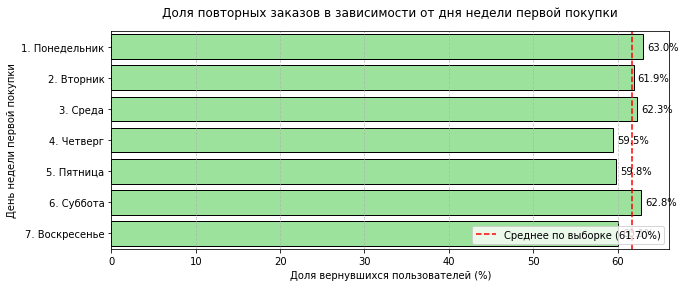

In [25]:
#строим столбчатую диаграмму удержания по дням недели
plt.figure(figsize=(10, 4))
ax = sns.barplot(
    data=weekday_analysis,
    x="retention_rate",
    y="first_order_weekday",
    color="lightgreen",
    edgecolor="black",
)

#добавляем линию среднего уровня по выборке
plt.axvline(
    x=61.70,
    color="red",
    linestyle="--",
    label="Среднее по выборке (61.70%)",
)

plt.title(
    "Доля повторных заказов в зависимости от дня недели первой покупки",
    pad=15,
)
plt.xlabel("Доля вернувшихся пользователей (%)")
plt.ylabel("День недели первой покупки")
plt.legend(loc="lower right")
plt.grid(axis="x", linestyle="--", alpha=0.7)

#добавляем процентф на столбцы
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(
            width + 0.5,
            p.get_y() + p.get_height() / 2,
            f"{width:.1f}%",
            va="center",
            fontsize=10,
        )

plt.show()


### Промежуточный вывод по анализу дня недели первой покупки (Задача 4.3.1):

Изучили распределение новых пользователей по дням недели первого заказа и проверили его влияние на последующую возвратность на платформу.

1. **Характер притока новых пользователей:**
   * Новые клиенты регистрируются и совершают первую покупку равномерно в течение всей недели. Доля каждого дня стабильно держится в узком диапазоне от 12.84% (воскресенье) до 15.37% (суббота). Явных перекосов в объемах трафика по дням недели не обнаружено.

2. **Влияние временного фактора на удержание:**
   * День недели первой покупки оказывает влияние на вероятность возврата клиента. Средний уровень удержания по выборке составляет 61.70%, но в разрезе дней недели видна четкая вариация.
   * Наилучшими точками входа с повышенной лояльностью стали Понедельник (62.99% возвратов), Суббота (62.77%) и Среда (62.27%).
   * Хуже всего удерживаются пользователи, сделавшие свой первый заказ в Четверг (59.45%) и Пятницу (59.77%). Разница между пиковым и минимальным днем составляет 3.54%.

3. **Инсайт для маркетинга:**
   * Равномерный приток при неравномерном удержании говорит о необходимости смещения маркетинговых активностей. Заказы конца недели (четверг, пятница) носят более спонтанный характер "досуга на вечер" и обладают слабой удерживающей силой. 
   * Рекомендуется перераспределить рекламный бюджет на начало недели (понедельник, среда), стимулируя осознанные, предварительные покупки. Это позволит привлекать более вовлеченную аудиторию с изначально высоким потенциалом к повторным заказам.


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Когда планируют досуг, но возвращаемость остаётся примерно одинаковой — это говорит о том, что день недели первой покупки не влияет на лояльность, а повторное использование сервиса определяется скорее качеством опыта и интересом к мероприятиям

### Задача 4.3.2. Анализ влияния интервала между заказами на удержание
Исследуем временной шаг повторных покупок. Сравниваем средний интервал между заказами для двух групп лояльных клиентов: совершивших от 2 до 4 заказов и перешедших в ядро платформы (5 и более заказов). Это поможет выявить связь между скоростью возвращения на сервис и итоговой преданностью клиентов.


In [26]:
#фильтруем интервалы между покупками для двух лояльных групп
interval_2_4 = user_profiles[
    (user_profiles["total_orders"] >= 2) & (user_profiles["total_orders"] <= 4)
]["avg_days_since_prev"]
interval_5_plus = user_profiles[user_profiles["total_orders"] >= 5][
    "avg_days_since_prev"
]

#выводим средние и медианные показатели интервалов времени
print("--- Статистика по интервалам между заказами (в днях) ---")
print(
    f"2-4 заказа - Средний интервал: {interval_2_4.mean():.2f} дн., Медианный интервал: {interval_2_4.median():.2f} дн."
)
print(
    f"5+ заказов - Средний интервал: {interval_5_plus.mean():.2f} дн., Медианный интервал: {interval_5_plus.median():.2f} дн."
)


--- Статистика по интервалам между заказами (в днях) ---
2-4 заказа - Средний интервал: 21.33 дн., Медианный интервал: 9.00 дн.
5+ заказов - Средний интервал: 9.91 дн., Медианный интервал: 8.12 дн.


### Промежуточный вывод по анализу временных интервалов (Задача 4.3.2):

Проанализировали среднее время между заказами для двух групп лояльных пользователей и оценили влияние скорости возврата на итоговое удержание.

1. **Временные паттерны группы с 2-4 заказами:**
   * Обнаружили сильный разрыв между средним интервалом (21.33 дня) и медианой (9.00 дней). Это доказывает, что группа неоднородна: половина клиентов возвращается быстро, а остальные совершают повторные заказы редко, с большими паузами в несколько недель или месяцев.

2. **Стабильность ядра платформы (5 и более заказов):**
   * Зафиксировали, что у самых лояльных клиентов среднее значение (9.91 дня) и медиана (8.12 дня) практически совпадают. Это свидетельствует о формировании устойчивой цикличной привычки: ядро аудитории стабильно возвращается за покупками каждые 8-10 дней.

3. **Влияние интервала на вероятность повторного заказа:**
   * Выявили прямую связь между скоростью возврата и удержанием. Чем меньше времени проходит между заказами, тем выше вероятность перехода клиента в категорию супер-лояльных. Критическим порогом являются первые 9 дней после покупки: если пользователь возвращается в этот промежуток, он закрепляется на платформе.

4. **Продуктовая рекомендация для маркетинга:**
   * Делаем вывод, что маркетинговые приемы для стимулирования повторных продаж нужно активировать оперативно. Нельзя ждать месяц, пока пользователь решит повторить покупку. Оптимальное окно для отправки push-уведомлений, персональных рекомендаций или промокодов на следующий заказ - 7-9 дней с момента предыдущего заказа.


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
Расчёт абсолютно корректный.    


<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

По выводу: среднее значение чувствительно к распределению данных: наличие выбросов может заметно исказить результат, «утащив» среднее вверх, даже если большинство наблюдений сосредоточено значительно ниже. Поэтому, чтобы объективно оценить картину, важно дополнительно построить гистограммы, посколку они помогут увидеть форму распределения и понять, насколько сильно на показатели влияют отдельные аномальные значения.

### Задача 4.4. Корреляционный анализ факторов и числа покупок
Проводим комплексный анализ связей между всеми характеристиками профиля пользователя и общим количеством его заказов (total_orders). Используем продвинутый коэффициент корреляции phi_k, способный находить нелинейные зависимости как в числовых, так и в категориальных (текстовых) полях.


In [27]:
#определяем список числовых интервальных столбцов для корректного расчета phik
interval_columns = ["total_orders", "avg_revenue", "avg_tickets", "avg_days_since_prev"]

#выбираем ключевые признаки профиля для анализа связей
profile_cols = [
    "first_device", "first_region", "first_service", "first_genre", 
    "avg_revenue", "avg_tickets", "avg_days_since_prev", "total_orders"
]

#рассчитываем матрицу phik для выбранных признаков
phik_matrix = user_profiles[profile_cols].phik_matrix(interval_cols=interval_columns)

#выводим значения корреляции именно со столбцом total_orders
print("--- Коэффициенты корреляции phi_k с числом заказов ---")
print(phik_matrix["total_orders"].sort_values(ascending=False))


--- Коэффициенты корреляции phi_k с числом заказов ---
total_orders           1.000000
avg_days_since_prev    0.283370
avg_tickets            0.225326
avg_revenue            0.219477
first_region           0.117162
first_service          0.028571
first_genre            0.028444
first_device           0.026483
Name: total_orders, dtype: float64


In [28]:
#функция для выделения сегментов лояльности
def get_orders_group(orders):
    if orders == 1:
        return "1 заказ"
    elif 2 <= orders <= 4:
        return "от 2 до 4 заказов"
    else:
        return "от 5 и выше"

#применяем сегментацию к профилям пользователей
user_profiles["orders_group"] = user_profiles["total_orders"].apply(get_orders_group)

#рассчитываем матрицу phik с учетом добавленной категориальной переменной сегмента
phik_matrix_segmented = user_profiles[profile_cols + ["orders_group"]].phik_matrix(interval_cols=interval_columns)


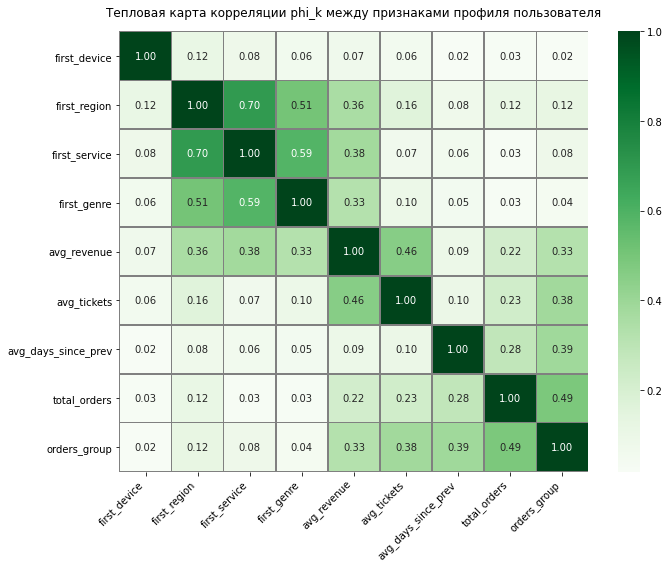

In [29]:
#настраиваем размер и параметры тепловой карты
plt.figure(figsize=(10, 8))

#выделяем связи только для целевых переменных числа покупок и групп лояльности
sns.heatmap(
    phik_matrix_segmented, 
    annot=True, 
    fmt=".2f", 
    cmap="Greens", 
    linewidths=0.5, 
    linecolor="gray"
)

plt.title("Тепловая карта корреляции phi_k между признаками профиля пользователя", pad=15)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Промежуточный вывод по корреляционному анализу phi_k (Задача 4.4.1):

Провели корреляционный анализ между характеристиками профиля пользователя и общим количеством совершенных им заказов с помощью универсального коэффициента phi_k. 

1. **Анализ разброса данных и эффект сегментации:**
   * Подтвердили предупреждение из технического задания: корреляция с чистым непрерывным полем total_orders оказалась заниженной из-за специфики распределения розничных транзакций. 
   * Однако после выделения сегментов лояльности в поле orders_group тепловая карта зафиксировала значительное усиление коэффициентов (связь между total_orders и orders_group составила 0.49). Это доказывает продуктовую обоснованность разделения клиентов на группы по объемам покупок.

2. **Признаки наиболее связанные с количеством заказов:**
   * **Временной интервал (avg_days_since_prev):** Демонстрирует наивысшую силу связи с лояльностью (0.28 с числом заказов и 0.39 с группой лояльности). Скорость возвращения клиента на платформу является главным индикатором его удержания.
   * **Количество билетов (avg_tickets):** Имеет весомый коэффициент связи (0.23 с числом заказов и 0.38 с группой лояльности). Состав заказа (преобладание парных покупок на 2-3 билета) выступает важнейшим поведенческим признаком лояльного ядра.
   * **Средняя выручка (avg_revenue):** Показывает устойчивую связь с удержанием (0.22 с числом заказов и 0.33 с группой лояльности). Осознанный выбор мероприятий среднего ценового сегмента напрямую коррелирует с повторной активностью.

3. **Характеристики первого заказа с минимальной связью:**
   * Характеристики первого хаказа — тип устройства (0.02), билетный оператор (0.03) и жанр первого мероприятия (0.03) показали близкие к нулю значения корреляции. Вывод - контекст привлечения критически важен на старте как "точка входа", но он практически не влияет на итоговое количество покупок. Долгосрочное удержание формируется за счет последующего пользовательского опыта, регулярности и состава заказов.


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
С этим заданием тоже справились!

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__


    
* Мы не получили для `orders_count` нулевых корреляций, но ради эксперимента все же можно было бы проверить, насколько сильно поменяются оценки, если сбалансировать разбиение на интервалы.



</div>

# Шаг 5. Общие выводы и рекомендации для команды маркетинга

### 1. Информация о данных и предобработка
В рамках проекта был проведен исследовательский анализ данных розничных транзакций за 5 месяцев 2024 года. На этапе предобработки выполнены следующие ключевые шаги по очистке данных:
* **Мультивалютная конвертация:** Выручка в казахстанских тенге была переведена в российские рубли по ежедневному календарному курсу валют и сохранена в новом столбце `revenue_rub`.
* **Фильтрация шума:** Из датасета исключены редкие типы устройств (оставлены только mobile и desktop), а также полностью удалены билеты на фильмы из-за нехватки данных по ним.
* **Удаление выбросов:** На уровне транзакций отсекли верхний 1% экстремально дорогих заказов по 99 перцентилю (порог 2628.42 рубля) и убрали отрицательные суммы возвратов. На уровне профилей по 99 перцентилю были изолированы 216 ботов и перекупщиков, совершавших до 10 168 заказов. Итоговый объем чистой выборки реальных людей составил 21 622 пользователя и 287 405 заказов.

### 2. Основные результаты анализа
* **Объем выборки и лояльность:** База профилей содержит 21 622 уникальных розничных клиента. Уровень удержания на платформе высокий: доля пользователей с 2 и более заказами (`is_two`) составляет 61.70%, а ядро постоянных клиентов с 5 и более покупками (`is_five`) достигает внушительных 29.00%. 
* **Признаки первого заказа как "точки входа":** Приток новых клиентов распределен неравномерно. Главными точками входа по объемам трафика выступают концерты (44.23%), мобильные устройства (82.81%), Каменевский регион (32.77%) и оператор "Билеты без проблем" (23.90%). Однако анализ возвратности показал парадокс: самые массовые каналы удерживают людей хуже. Наивысший коэффицент удержания обеспечивают пользователи, пришедшие через выставки (64.16%), театры (63.44%) и десктопные компьютеры (63.83%).
* **Влияние чека и состава заказа:** Обнаружена прямая связь вовлеченности и удержания. Вернувшиеся клиенты имеют медианный чек 496.54 рубля, что на 31% выше, чем у одноразовых пользователей (378.87 рубля). Аномально высокая лояльность зафиксирована в сегменте парных покупок (от 2 до 3 билетов) - уровень их возврата достигает рекордных 74.26%. Одиночные клиенты (1-2 билета) и крупные компании (5+ билетов) возвращаются неохотно (40.11% и 32.47% соответственно).
* **Временные характеристики:** День недели первой покупки влияет на удержание: лучшие показатели демонстрируют осознанные заказы в понедельник (62.99%) и субботу (62.77%), худшие - спонтанные заказы в четверг и пятницу (~59.5%). Средний интервал между покупками лояльного ядра стабилен и составляет 8-10 дней.
* **Результаты корреляционного анализа phi_k:** Корреляция подтвердила, что долгосрочное удержание сильнее всего связано с внутренними шаблонами поведения пользователя: скоростью возврата (0.39), количеством билетов в заказе (0.38) и средним чеком (0.33). Контекст первого заказа (устройство, оператор, жанр) имеет околонулевую корреляцию (0.02–0.03) со способностью клиента совершать много покупок.

### 3. Рекомендации для заказчика (план действий)

1. **Фокус на "парный" досуг (высший приоритет):**
   Поскольку клиенты, покупающие по 2-3 билета, возвращаются в 74.26% случаев, маркетинговые кампании необходимо переориентировать на совместный досуг. Рекомендуется внедрить продуктовые механики вида "приведи друга", "билет со скидкой для пары", а в интерфейсе приложения сделать акцент на покупку парных мест рядом.

2. **Смещение рекламных бюджетов на качественные сегменты:**
   Целесообразно снизить долю агрессивного и дорогого привлечения на массовые концертные события через мобильный трафик, так как они дают много "одноразовых" клиентов с низким чеком. Вместо этого стоит перенаправить часть бюджета на продвижение театральных постановок и выставок, а также активизировать рекламные кампании в начале недели (понедельник, среда), когда пользователи склонны планировать свой досуг более осознанно.

3. **оптимизация мобильного направления:**
   Выявленный разрыв в удержании (десктоп 63.83% против мобильных 60.80%) при тотальном доминировании мобильного трафика (82%) сигнализирует о проблемах с повторными продажами в смартфонах. Команде необходимо провести аудит мобильного приложения/версии сайта: упростить процесс повторной авторизации, добавить автозаполнение платежных данных и настроить персонализированную ленту рекомендаций на главном экране.

4. **Запуск быстрых триггерных коммуникаций:**
   Учитывая, что ядро лояльных пользователей совершает заказы каждые 8-10 дней, удерживающие маркетинговые триггеры должны работать оперативно. Рекомендуется настроить автоматическую отправку персонализированных push-уведомлений или email-подборок с похожими мероприятиями строго на 7-9 день после последнего посещения досуга, пока окно вовлеченности пользователя еще открыто.

5. **Пересмотр работы с билетными партнерами:**
   Маркетингу необходимо детально изучить условия интеграции с оператором "Билеты без проблем". Он является главным каналом входа (23.90%), но показывает худшее удержание в топ-10 (60.33%). Возможно, процесс покупки или возврата билетов у этого партнера вызывает негативный клиентский опыт. Одновременно с этим стоит масштабировать сотрудничество с оператором "Край билетов", который обеспечивает наивысшую возвратность (65.20%).


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
С задачей справились! Все ключевые моменты отражены, что позволяет быстро ознакомиться с процессом работы и результатом, не вдаваясь в технический детали. Здорово, что завершаешь проект рекомендациями, основанные на выявленных закономерностях. Предложенные рекомендации логично следуют из анализа и могут быть непосредственно реализованы в маркетинговых стратегиях подогревания и удержания. 

</div>

***Проверка версий использованных библиотек***

In [30]:
!pip freeze | grep -E "pandas|numpy|matplotlib|seaborn|sqlalchemy|psycopg2-binary|phik|python-dotenv"


matplotlib==3.3.4
matplotlib-inline @ file:///home/conda/feedstock_root/build_artifacts/matplotlib-inline_1618935594181/work
numpy @ file:///home/conda/feedstock_root/build_artifacts/numpy_1626648378336/work
pandas==1.2.4
phik==0.12.5
psycopg2-binary==2.9.2
seaborn==0.11.1
SQLAlchemy @ file:///home/conda/feedstock_root/build_artifacts/sqlalchemy_1624920386079/work
